In [41]:
pip install numpy pandas matplotlib seaborn scikit-learn category_encoders

Note: you may need to restart the kernel to use updated packages.


In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.preprocessing import (
    MinMaxScaler,
    StandardScaler,
    RobustScaler,
    MaxAbsScaler,
    LabelEncoder
)
from sklearn.feature_selection import SelectKBest, f_classif

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [43]:
#1. Load Dataset and Identify Missing Values
# Load Titanic dataset
titanic = fetch_openml("titanic", version=1, as_frame=True)

df = titanic.frame.copy()

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1309, 14)


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [44]:
# Missing values in each column
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
pclass          0
survived        0
name            0
sex             0
age           263
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
dtype: int64


In [45]:
#2. Percentage of Missing Values
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": missing_percentage
})

missing_table.sort_values(
    by="Missing Percentage",
    ascending=False
)

,Missing Values,Missing Percentage
body,1188,90.756303
cabin,1014,77.463713
boat,823,62.872422
home.dest,564,43.086325
age,263,20.091673
embarked,2,0.152788
fare,1,0.076394
pclass,0,0.000000
survived,0,0.000000
name,0,0.000000


In [46]:
#3. Remove Rows Containing Missing Values
df_drop_rows = df.dropna()

print("Original Shape:", df.shape)
print("After Removing Missing Rows:", df_drop_rows.shape)

Original Shape: (1309, 14)
After Removing Missing Rows: (0, 14)


In [47]:
#4. Remove Columns Having More Than 50% Missing Values
threshold = 50

missing_percentage = df.isnull().mean() * 100

columns_to_remove = missing_percentage[
    missing_percentage > threshold
].index

df_drop_columns = df.drop(columns=columns_to_remove)

print("Removed Columns:")
print(list(columns_to_remove))

print("\nNew Shape:", df_drop_columns.shape)

Removed Columns:
['cabin', 'boat', 'body']

New Shape: (1309, 11)


In [48]:
#5. Replace Missing Numerical Values Using Mean
df_mean = df.copy()

numeric_columns = df_mean.select_dtypes(
    include=np.number
).columns

for col in numeric_columns:
    df_mean[col] = df_mean[col].fillna(
        df_mean[col].mean()
    )

print("Missing values after Mean Imputation:")
print(df_mean[numeric_columns].isnull().sum())

Missing values after Mean Imputation:
pclass    0
age       0
sibsp     0
parch     0
fare      0
body      0
dtype: int64


In [49]:
#6. Replace Missing Numerical Values Using Median
df_median = df.copy()

numeric_columns = df_median.select_dtypes(
    include=np.number
).columns

for col in numeric_columns:
    df_median[col] = df_median[col].fillna(
        df_median[col].median()
    )

print("Missing values after Median Imputation:")
print(df_median[numeric_columns].isnull().sum())

Missing values after Median Imputation:
pclass    0
age       0
sibsp     0
parch     0
fare      0
body      0
dtype: int64


In [50]:
df_mode = df.copy()

categorical_columns = df_mode.select_dtypes(
    exclude=np.number
).columns

for col in categorical_columns:
    if df_mode[col].isnull().any():
        df_mode[col] = df_mode[col].fillna(
            df_mode[col].mode()[0]
        )

print("Missing values after Mode Imputation:")
print(df_mode[categorical_columns].isnull().sum())

Missing values after Mode Imputation:
survived     0
name         0
sex          0
ticket       0
cabin        0
embarked     0
boat         0
home.dest    0
dtype: int64


In [51]:
df_ffill = df.copy()

df_ffill = df_ffill.ffill()

print("Missing values after Forward Fill:")
print(df_ffill.isnull().sum())

Missing values after Forward Fill:
pclass       0
survived     0
name         0
sex          0
age          0
sibsp        0
parch        0
ticket       0
fare         0
cabin        0
embarked     0
boat         0
body         3
home.dest    0
dtype: int64


In [52]:
df_bfill = df.copy()

df_bfill = df_bfill.bfill()

print("Missing values after Backward Fill:")
print(df_bfill.isnull().sum())

Missing values after Backward Fill:
pclass        0
survived      0
name          0
sex           0
age           0
sibsp         0
parch         0
ticket        0
fare          0
cabin        59
embarked      0
boat          9
body          2
home.dest    27
dtype: int64


In [53]:
comparison_missing = pd.DataFrame({
    "Before": df.isnull().sum(),
    "Mean": df_mean.isnull().sum(),
    "Median": df_median.isnull().sum(),
    "Mode": df_mode.isnull().sum(),
    "Forward Fill": df_ffill.isnull().sum(),
    "Backward Fill": df_bfill.isnull().sum()
})

comparison_missing

,Before,Mean,Median,Mode,Forward Fill,Backward Fill
pclass,0,0,0,0,0,0
survived,0,0,0,0,0,0
name,0,0,0,0,0,0
sex,0,0,0,0,0,0
age,263,0,0,263,0,0
sibsp,0,0,0,0,0,0
parch,0,0,0,0,0,0
ticket,0,0,0,0,0,0
fare,1,0,0,1,0,0
cabin,1014,1014,1014,0,0,59


In [54]:
# Use age and fare for outlier analysis
outlier_data = df[["age", "fare"]].copy()

for col in outlier_data.columns:
    Q1 = outlier_data[col].quantile(0.25)
    Q3 = outlier_data[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = outlier_data[
        (outlier_data[col] < lower_bound) |
        (outlier_data[col] > upper_bound)
    ]

    print(f"{col}: {len(outliers)} outliers")

age: 9 outliers
fare: 171 outliers


In [55]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [56]:
from scipy.stats import zscore

zscore_data = df[["age", "fare"]].dropna().copy()

z_scores = np.abs(zscore(zscore_data))

for i, col in enumerate(zscore_data.columns):
    outliers = zscore_data[z_scores[:, i] > 3]

    print(f"{col}: {len(outliers)} outliers")

age: 3 outliers
fare: 36 outliers


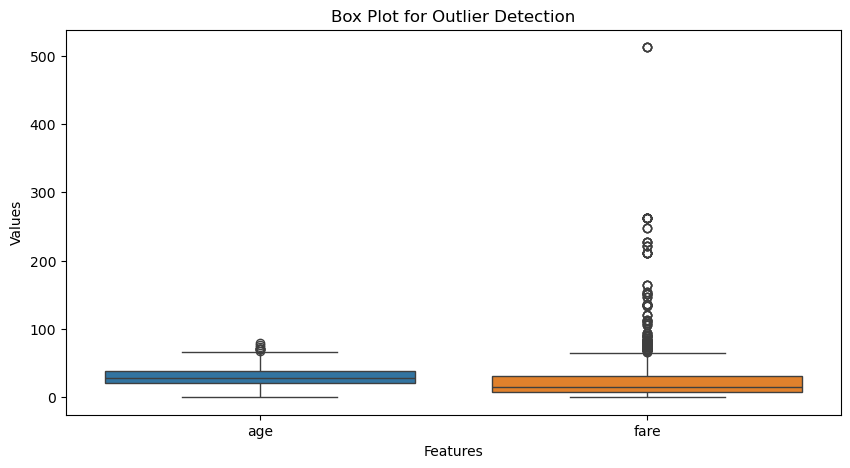

In [57]:
plt.figure(figsize=(10, 5))

sns.boxplot(data=df[["age", "fare"]])

plt.title("Box Plot for Outlier Detection")
plt.xlabel("Features")
plt.ylabel("Values")

plt.show()

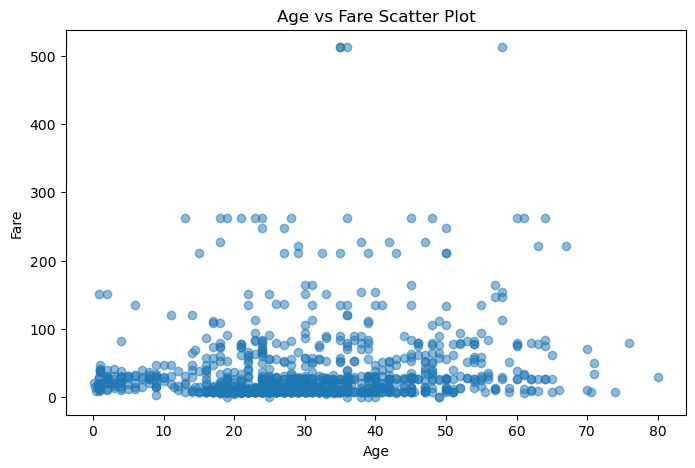

In [58]:
plt.figure(figsize=(8, 5))

plt.scatter(df["age"], df["fare"], alpha=0.5)

plt.title("Age vs Fare Scatter Plot")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.show()

In [59]:
df_iqr = df.copy()

for col in ["age", "fare"]:

    Q1 = df_iqr[col].quantile(0.25)
    Q3 = df_iqr[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_iqr = df_iqr[
        (df_iqr[col].isna()) |
        (
            (df_iqr[col] >= lower) &
            (df_iqr[col] <= upper)
        )
    ]

print("Original Shape:", df.shape)
print("After IQR Outlier Removal:", df_iqr.shape)

Original Shape: (1309, 14)
After IQR Outlier Removal: (1132, 14)


In [60]:
df_outlier_median = df.copy()

for col in ["age", "fare"]:

    median = df_outlier_median[col].median()

    Q1 = df_outlier_median[col].quantile(0.25)
    Q3 = df_outlier_median[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    mask = (
        (df_outlier_median[col] < lower) |
        (df_outlier_median[col] > upper)
    )

    df_outlier_median.loc[mask, col] = median

print("Outliers replaced with median.")

Outliers replaced with median.


In [61]:
df_capped = df.copy()

for col in ["age", "fare"]:

    lower = df_capped[col].quantile(0.01)
    upper = df_capped[col].quantile(0.99)

    df_capped[col] = df_capped[col].clip(
        lower=lower,
        upper=upper
    )

print("Percentile-based capping completed.")

Percentile-based capping completed.


In [62]:
print("Original Dataset:")
display(df[["age", "fare"]].describe())

print("\nAfter IQR Removal:")
display(df_iqr[["age", "fare"]].describe())

print("\nAfter Median Replacement:")
display(df_outlier_median[["age", "fare"]].describe())

print("\nAfter Percentile Capping:")
display(df_capped[["age", "fare"]].describe())

Original Dataset:


,age,fare
count,1046.000000,1308.000000
mean,29.881135,33.295479
std,14.413500,51.758668
min,0.166700,0.000000
25%,21.000000,7.895800
50%,28.000000,14.454200
75%,39.000000,31.275000
max,80.000000,512.329200



After IQR Removal:


,age,fare
count,887.000000,1131.000000
mean,28.442221,17.933418
std,13.482804,13.812781
min,0.166700,0.000000
25%,20.000000,7.879200
50%,27.000000,13.000000
75%,36.000000,26.000000
max,66.000000,65.000000



After Median Replacement:


,age,fare
count,1046.000000,1308.000000
mean,29.501115,17.503476
std,13.860718,12.947668
min,0.166700,0.000000
25%,21.000000,7.895800
50%,28.000000,14.454200
75%,38.000000,23.587500
max,66.000000,65.000000



After Percentile Capping:


,age,fare
count,1046.000000,1308.000000
mean,29.821224,32.528226
std,14.234658,46.210046
min,0.916700,0.000000
25%,21.000000,7.895800
50%,28.000000,14.454200
75%,39.000000,31.275000
max,65.000000,262.375000


In [63]:
scaler_minmax = MinMaxScaler()

numeric_data = df[["age", "fare"]].copy()
numeric_data = numeric_data.fillna(
    numeric_data.median()
)

minmax_data = scaler_minmax.fit_transform(numeric_data)

df_minmax = pd.DataFrame(
    minmax_data,
    columns=["age", "fare"]
)

df_minmax.head()

,age,fare
0,0.361169,0.412503
1,0.009395,0.295806
2,0.022964,0.295806
3,0.373695,0.295806
4,0.311064,0.295806


In [64]:
scaler_standard = StandardScaler()

standard_data = scaler_standard.fit_transform(
    numeric_data
)

df_standard = pd.DataFrame(
    standard_data,
    columns=["age", "fare"]
)

df_standard.head()

,age,fare
0,-0.039005,3.442584
1,-2.215952,2.286639
2,-2.131977,2.286639
3,0.038512,2.286639
4,-0.349075,2.286639


In [65]:
scaler_robust = RobustScaler()

robust_data = scaler_robust.fit_transform(
    numeric_data
)

df_robust = pd.DataFrame(
    robust_data,
    columns=["age", "fare"]
)

df_robust.head()

,age,fare
0,0.076923,8.421302
1,-2.083331,5.864007
2,-2.000000,5.864007
3,0.153846,5.864007
4,-0.230769,5.864007


In [67]:
from sklearn.preprocessing import MaxAbsScaler

# Apply MaxAbsScaler
scaler = MaxAbsScaler()
df_maxabs = pd.DataFrame(
    scaler.fit_transform(numeric_data),
    columns=numeric_data.columns
)

# Now your comparison will work
comparison_scaling = pd.DataFrame({
    "Original Age": numeric_data["age"],
    "MinMax Age": df_minmax["age"],
    "Standard Age": df_standard["age"],
    "Robust Age": df_robust["age"],
    "MaxAbs Age": df_maxabs["age"]
})

print(comparison_scaling.head(10))


   Original Age  MinMax Age  Standard Age  Robust Age  MaxAbs Age
0       29.0000    0.361169     -0.039005    0.076923    0.362500
1        0.9167    0.009395     -2.215952   -2.083331    0.011459
2        2.0000    0.022964     -2.131977   -2.000000    0.025000
3       30.0000    0.373695      0.038512    0.153846    0.375000
4       25.0000    0.311064     -0.349075   -0.230769    0.312500
5       48.0000    0.599165      1.433827    1.538462    0.600000
6       63.0000    0.787056      2.596589    2.692308    0.787500
7       39.0000    0.486430      0.736169    0.846154    0.487500
8       53.0000    0.661795      1.821414    1.923077    0.662500
9       71.0000    0.887265      3.216729    3.307692    0.887500


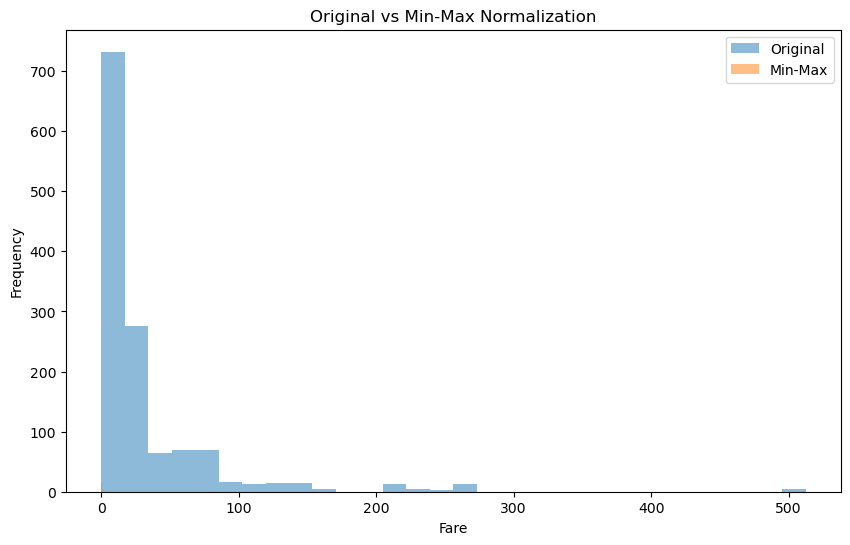

In [68]:
plt.figure(figsize=(10, 6))

plt.hist(
    numeric_data["fare"],
    bins=30,
    alpha=0.5,
    label="Original"
)

plt.hist(
    df_minmax["fare"],
    bins=30,
    alpha=0.5,
    label="Min-Max"
)

plt.title("Original vs Min-Max Normalization")
plt.xlabel("Fare")
plt.ylabel("Frequency")

plt.legend()
plt.show()

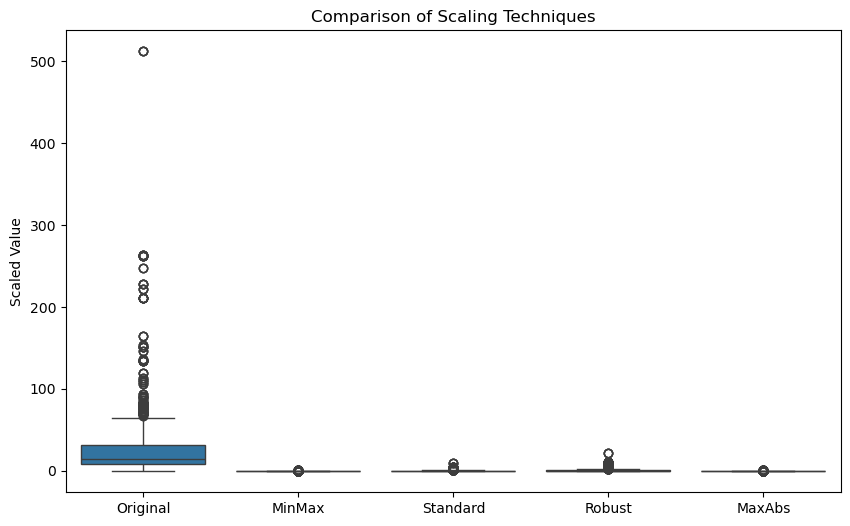

In [69]:
scaling_box = pd.DataFrame({
    "Original": numeric_data["fare"],
    "MinMax": df_minmax["fare"],
    "Standard": df_standard["fare"],
    "Robust": df_robust["fare"],
    "MaxAbs": df_maxabs["fare"]
})

plt.figure(figsize=(10, 6))

sns.boxplot(data=scaling_box)

plt.title("Comparison of Scaling Techniques")
plt.ylabel("Scaled Value")

plt.show()

In [70]:
scaling_comparison = pd.DataFrame({
    "Original": numeric_data["fare"].head(10).values,
    "Min-Max": df_minmax["fare"].head(10).values,
    "Standard": df_standard["fare"].head(10).values,
    "Robust": df_robust["fare"].head(10).values,
    "Max Absolute": df_maxabs["fare"].head(10).values
})

scaling_comparison

,Original,Min-Max,Standard,Robust,Max Absolute
0,211.3375,0.412503,3.442584,8.421302,0.412503
1,151.5500,0.295806,2.286639,5.864007,0.295806
2,151.5500,0.295806,2.286639,5.864007,0.295806
3,151.5500,0.295806,2.286639,5.864007,0.295806
4,151.5500,0.295806,2.286639,5.864007,0.295806
5,26.5500,0.051822,-0.130140,0.517374,0.051822
6,77.9583,0.152164,0.863800,2.716265,0.152164
7,0.0000,0.000000,-0.643464,-0.618250,0.000000
8,51.4792,0.100481,0.351847,1.583673,0.100481
9,49.5042,0.096626,0.313661,1.499196,0.096626


In [71]:
label_encoder = LabelEncoder()

df_label = df.copy()

df_label["sex_encoded"] = label_encoder.fit_transform(
    df_label["sex"].astype(str)
)

df_label[["sex", "sex_encoded"]].head(10)

,sex,sex_encoded
0,female,0
1,male,1
2,female,0
3,male,1
4,female,0
5,male,1
6,female,0
7,male,1
8,female,0
9,male,1


In [72]:
df_onehot = df.copy()

df_onehot = pd.get_dummies(
    df_onehot,
    columns=["sex"],
    dtype=int
)

df_onehot.head()

,pclass,survived,name,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,sex_female,sex_male
0,1,1,"Allen, Miss. Elisabeth Walton",29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO",1,0
1,1,1,"Allison, Master. Hudson Trevor",0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON",0,1
2,1,0,"Allison, Miss. Helen Loraine",2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",1,0
3,1,0,"Allison, Mr. Hudson Joshua Creighton",30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON",0,1
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",1,0


In [73]:
import category_encoders as ce

df_binary = df.copy()

encoder = ce.BinaryEncoder(
    cols=["embarked"],
    return_df=True
)

df_binary = encoder.fit_transform(
    df_binary
)

df_binary.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked_0,embarked_1,embarked_2,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,0,0,1,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,0,0,1,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,0,0,1,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,0,0,1,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,0,0,1,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [74]:
df_feature = df.copy()

df_feature["FamilySize"] = (
    df_feature["sibsp"] +
    df_feature["parch"] +
    1
)

df_feature[
    ["sibsp", "parch", "FamilySize"]
].head(10)

,sibsp,parch,FamilySize
0,0,0,1
1,1,2,4
2,1,2,4
3,1,2,4
4,1,2,4
5,0,0,1
6,1,0,2
7,0,0,1
8,2,0,3
9,0,0,1


In [75]:
df_date = df.copy()

df_date["TravelDate"] = pd.date_range(
    start="2020-01-01",
    periods=len(df_date),
    freq="D"
)

df_date["Year"] = df_date["TravelDate"].dt.year
df_date["Month"] = df_date["TravelDate"].dt.month
df_date["Day"] = df_date["TravelDate"].dt.day

df_date[
    ["TravelDate", "Year", "Month", "Day"]
].head()

,TravelDate,Year,Month,Day
0,2020-01-01,2020,1,1
1,2020-01-02,2020,1,2
2,2020-01-03,2020,1,3
3,2020-01-04,2020,1,4
4,2020-01-05,2020,1,5


In [76]:
df_math = df.copy()

df_math["Fare_Sqrt"] = np.sqrt(
    df_math["fare"].fillna(
        df_math["fare"].median()
    )
)

df_math[["fare", "Fare_Sqrt"]].head()

,fare,Fare_Sqrt
0,211.3375,14.537452
1,151.5500,12.310565
2,151.5500,12.310565
3,151.5500,12.310565
4,151.5500,12.310565


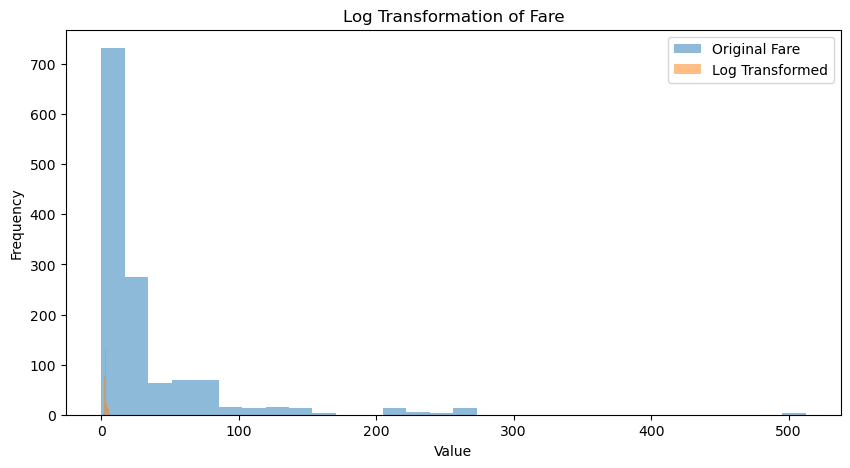

In [77]:
df_log = df.copy()

df_log["Fare_Log"] = np.log1p(
    df_log["fare"].fillna(
        df_log["fare"].median()
    )
)

plt.figure(figsize=(10, 5))

plt.hist(
    df_log["fare"].fillna(df_log["fare"].median()),
    bins=30,
    alpha=0.5,
    label="Original Fare"
)

plt.hist(
    df_log["Fare_Log"],
    bins=30,
    alpha=0.5,
    label="Log Transformed"
)

plt.title("Log Transformation of Fare")
plt.xlabel("Value")
plt.ylabel("Frequency")

plt.legend()
plt.show()

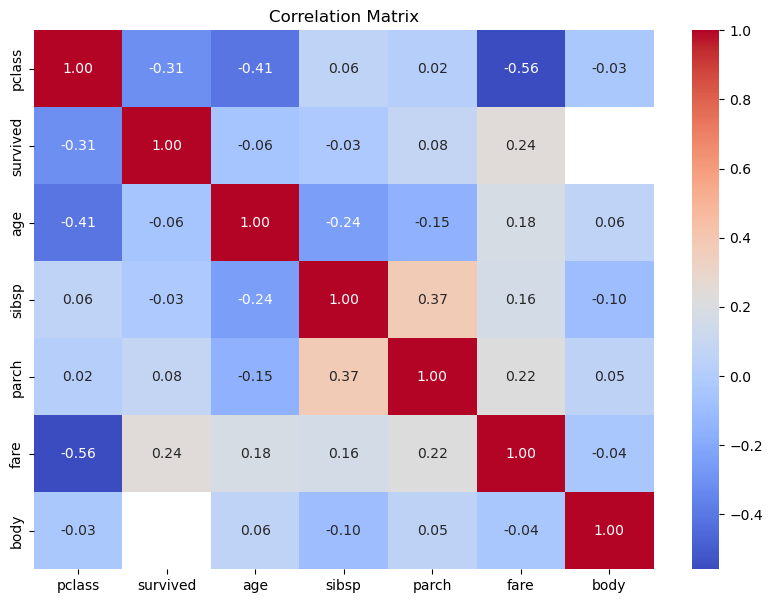

In [78]:
df_corr = df.copy()

# Convert survived to numeric
df_corr["survived"] = pd.to_numeric(
    df_corr["survived"],
    errors="coerce"
)

# Select numeric columns
numeric_corr = df_corr.select_dtypes(
    include=np.number
)

correlation_matrix = numeric_corr.corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [79]:
target_corr = (
    correlation_matrix["survived"]
    .sort_values(ascending=False)
)

print("Correlation with Target:")
print(target_corr)

Correlation with Target:
survived    1.000000
fare        0.244265
parch       0.082660
sibsp      -0.027825
age        -0.055513
pclass     -0.312469
body             NaN
Name: survived, dtype: float64


In [80]:
final_df = df.copy()

# ------------------------------------------------
# 1. Convert target to numeric
# ------------------------------------------------

final_df["survived"] = pd.to_numeric(
    final_df["survived"],
    errors="coerce"
)

# ------------------------------------------------
# 2. Drop unnecessary columns
# ------------------------------------------------

columns_to_drop = [
    "boat",
    "body",
    "home.dest",
    "name",
    "ticket",
    "cabin"
]

final_df = final_df.drop(
    columns=columns_to_drop,
    errors="ignore"
)

# ------------------------------------------------
# 3. Fill numerical missing values with median
# ------------------------------------------------

numeric_cols = final_df.select_dtypes(
    include=np.number
).columns

for col in numeric_cols:
    final_df[col] = final_df[col].fillna(
        final_df[col].median()
    )

# ------------------------------------------------
# 4. Fill categorical missing values with mode
# ------------------------------------------------

categorical_cols = final_df.select_dtypes(
    exclude=np.number
).columns

for col in categorical_cols:
    if final_df[col].isnull().any():
        final_df[col] = final_df[col].fillna(
            final_df[col].mode()[0]
        )

# ------------------------------------------------
# 5. Create FamilySize
# ------------------------------------------------

if "sibsp" in final_df.columns and "parch" in final_df.columns:
    final_df["FamilySize"] = (
        final_df["sibsp"] +
        final_df["parch"] +
        1
    )

# ------------------------------------------------
# 6. One-Hot Encode categorical columns
# ------------------------------------------------

final_df = pd.get_dummies(
    final_df,
    drop_first=True,
    dtype=int
)

# ------------------------------------------------
# 7. Remove remaining missing rows
# ------------------------------------------------

final_df = final_df.dropna()

print("Final Dataset Shape:", final_df.shape)

display(final_df.head())

Final Dataset Shape: (1309, 10)


,pclass,survived,age,sibsp,parch,fare,FamilySize,sex_male,embarked_Q,embarked_S
0,1,1,29.0000,0,0,211.3375,1,0,0,1
1,1,1,0.9167,1,2,151.5500,4,1,0,1
2,1,0,2.0000,1,2,151.5500,4,0,0,1
3,1,0,30.0000,1,2,151.5500,4,1,0,1
4,1,0,25.0000,1,2,151.5500,4,0,0,1
